# Global Fishing Watch Vessels Voyages processing for Web Map

**ETL Data processing with Python**

This notebook process the `named ahchorages` and `voyages` datasets from Global Fishing Watch and optimize them for web map display.

*Version v3 Notes:*
- This version does not builds polylines for vessel movement visualization.
- Instead, it optimized datetime data for an appropiate display on web.

**Main Steps:**
- Loading CSV into GeoDataFrames
- Inspecting fields and basic EDA
- Inspecting geometry types, CRS, and basic statistics
- Data transformations
- Exporting results into GeoJSON

## Setup and Imports

In [1]:
# Import libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Display all columns in DataFrames
pd.set_option('display.max_columns', None)

print(f"GeoPandas version: {gpd.__version__}")

GeoPandas version: 1.1.3


## Load GFW anchorages

The anchorages dataset is a global dataset of anchorage locations where vessels congregate. Click [here](https://globalfishingwatch.org/data-download/datasets/public-anchorages%3Av20200316) for more information.


In [2]:
# importa anchorage dataset
anch = pd.read_csv(
    "./data/raw/named_anchorages_v2_pipe_v3_202601.csv",
    #"./data/raw/named_anchorages_v2_pipe_v4_202606.csv",
    low_memory=False
)

print(f"Shape: {anch.shape}")
anch.head()

Shape: (166497, 10)


,s2id,lat,lon,label,sublabel,label_source,iso3,distance_from_shore_m,drift_radius,dock
0,2df58a83,-0.001372,117.587306,BONTANG,BONTANG,top_destination,IDN,NaN,0.146807,False
1,2df58a9d,-0.001525,117.582562,BONTANG,BONTANG,top_destination,IDN,NaN,0.144518,False
2,0d620075,38.629273,-0.002665,ESP-2,MEDITERRAN SEA,anchorage_overrides,ESP,NaN,0.081794,True
3,48789d7d,53.600939,-0.001810,IMMINGHAM,IMMINGHAM,top_destination,GBR,NaN,0.112376,False
4,48789d7f,53.601836,-0.002068,IMMINGHAM,GRIMSBY,top_destination,GBR,NaN,0.111019,False


### Schema
| Column  | Description |
| --------- | -------------------------------- | 
| s2id      | unique anchorage identifier   |
| lat       | latitude in decimal degrees   |
| lon       | longitude in decimal degrees  |
| label     | anchorage label (broader port label) |
| sublabel  | anchorage sublabel (detailed anchorage label) |
| label_source  | source of label. Possible values included in table below  |
| iso3      | ISO3 code of the EEZ containing the anchorage |
| distance_from_shore_m | distance (meters) of the anchorage from shore |
| drift_radius          | average drift radius (meters) of vessels at the anchorage |
| dock      | is the anchorage located at a dock |

**`label_source` values**
| Value | Description   |
| ----- | ------------- |
| `top_destination` | the top destination as reported in the AIS messages of the stationary vessels that were used to define the anchorage | 
| `anchorage_overrides` | list of manual corrections to known anchorages |
| `WPI_ports` | World Port Index |
| `china_s2id_override` | Chinese anchorages where the `s2id` is used due to uncertainty in the name applied from other mechanisms | 
| `geonames_1000` | Geonames 100 database | 
| `indonesia` | Regional port database from the Indonesian Ministry of Marine Affairs and Fisheries |

### Transformation

In [3]:
# df to geodataframe
anch_gdf = gpd.GeoDataFrame(
    anch, geometry= gpd.points_from_xy(anch["lon"], anch["lat"]),
    crs="EPSG:4326"  # WGS84 longitude/latitude
)

anch_gdf.head()

,s2id,lat,lon,label,sublabel,label_source,iso3,distance_from_shore_m,drift_radius,dock,geometry
0,2df58a83,-0.001372,117.587306,BONTANG,BONTANG,top_destination,IDN,NaN,0.146807,False,POINT (117.58731 -0.00137)
1,2df58a9d,-0.001525,117.582562,BONTANG,BONTANG,top_destination,IDN,NaN,0.144518,False,POINT (117.58256 -0.00153)
2,0d620075,38.629273,-0.002665,ESP-2,MEDITERRAN SEA,anchorage_overrides,ESP,NaN,0.081794,True,POINT (-0.00267 38.62927)
3,48789d7d,53.600939,-0.001810,IMMINGHAM,IMMINGHAM,top_destination,GBR,NaN,0.112376,False,POINT (-0.00181 53.60094)
4,48789d7f,53.601836,-0.002068,IMMINGHAM,GRIMSBY,top_destination,GBR,NaN,0.111019,False,POINT (-0.00207 53.60184)


In [4]:
# drop columns
anch_gdf = anch_gdf.drop(
    columns= ["lat", "lon", "label_source", "distance_from_shore_m", "drift_radius"]
    )

anch_gdf.head()

,s2id,label,sublabel,iso3,dock,geometry
0,2df58a83,BONTANG,BONTANG,IDN,False,POINT (117.58731 -0.00137)
1,2df58a9d,BONTANG,BONTANG,IDN,False,POINT (117.58256 -0.00153)
2,0d620075,ESP-2,MEDITERRAN SEA,ESP,True,POINT (-0.00267 38.62927)
3,48789d7d,IMMINGHAM,IMMINGHAM,GBR,False,POINT (-0.00181 53.60094)
4,48789d7f,IMMINGHAM,GRIMSBY,GBR,False,POINT (-0.00207 53.60184)


In [5]:
# inspecting data types
anch_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 166497 entries, 0 to 166496
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype   
---  ------    --------------   -----   
 0   s2id      166497 non-null  str     
 1   label     166497 non-null  str     
 2   sublabel  160198 non-null  str     
 3   iso3      166497 non-null  str     
 4   dock      166477 non-null  object  
 5   geometry  166497 non-null  geometry
dtypes: geometry(1), object(1), str(4)
memory usage: 12.0+ MB


In [6]:
# dock to boolean
anch_gdf["dock"] = anch_gdf["dock"].astype(bool)

In [7]:
# find unique values
print(anch_gdf.nunique())
print()
print(anch_gdf.shape)

s2id        166497
label        14627
sublabel     31163
iso3           209
dock             2
geometry    166497
dtype: int64

(166497, 6)


In [8]:
# counting NAs
print(anch_gdf.isna().sum())

s2id           0
label          0
sublabel    6299
iso3           0
dock           0
geometry       0
dtype: int64


The column `s2id` has an unique count of 166,497 values which that matches the number of rows in the dataset. It indicates that `s2id` is the primary key of the anchorage dataset. The `dock` column indicates that some anchorage points are docks.

### Processing Labels 

In [9]:
# inspecting label levels 1, 2 and 3
anch_gdf[["iso3", "label", "sublabel"]].drop_duplicates()

,iso3,label,sublabel
0,IDN,BONTANG,BONTANG
2,ESP,ESP-2,MEDITERRAN SEA
3,GBR,IMMINGHAM,IMMINGHAM
4,GBR,IMMINGHAM,GRIMSBY
5,GBR,LONDON,CANARY WHARF
...,...,...,...
166489,USA,FOURCHON ANCHORAGE,FOURCHON
166492,USA,FOURCHON ANCHORAGE,KC 875
166493,USA,FOURCHON ANCHORAGE,KC875
166495,COK,COK-1,BDOCKX00030


In [10]:
# keeping label level 1 and 2
labels = anch_gdf[["s2id", "iso3", "label"]].drop_duplicates()

print(labels.shape)

(166497, 3)


In [11]:
# Capitalize Labels
labels["label"] = labels["label"].where(
    # find cases that follow the pattern, i.e: 'CAN-123'
    labels["label"].str.contains(r"\b[A-Z]+-\d+\b|\b[A-Z]+-NA\b"),
    # changes the cases that does not follow the pattern
    labels["label"].str.title()
)

In [12]:
# Validate if it worked properly
labels["label"]

0                    Bontang
1                    Bontang
2                      ESP-2
3                  Immingham
4                  Immingham
                 ...        
166492    Fourchon Anchorage
166493    Fourchon Anchorage
166494    Fourchon Anchorage
166495                 COK-1
166496                 COK-1
Name: label, Length: 166497, dtype: str

In [13]:
# import iso3-1 country names
iso3_country = pd.read_csv(
    "./data/raw/iso_3166_1.csv",
    low_memory=False
)

print(f"Shape: {iso3_country.shape}")
iso3_country.head()

Shape: (249, 4)


,Country,Alpha-2,Alpha-3,Numeric
0,Afghanistan,AF,AFG,4
1,Albania,AL,ALB,8
2,Algeria,DZ,DZA,12
3,American Samoa,AS,ASM,16
4,Andorra,AD,AND,20


In [14]:
# renaming columns
iso3_country = iso3_country.rename(
    columns= {
        "Alpha-3": "iso3",
        "Country" : "country"
    }
)

In [15]:
# matching iso3 with country names
labels = labels.merge(
    iso3_country[["iso3", "country"]],
    how = 'left',
)

labels.head()

,s2id,iso3,label,country
0,2df58a83,IDN,Bontang,Indonesia
1,2df58a9d,IDN,Bontang,Indonesia
2,0d620075,ESP,ESP-2,Spain
3,48789d7d,GBR,Immingham,United Kingdom of Great Britain and Northern I...
4,48789d7f,GBR,Immingham,United Kingdom of Great Britain and Northern I...


In [16]:
# renaming columns
labels = labels.rename(
    columns= {
        "label": "port"
    }
)

# re-organizing labels df
labels = labels[["s2id", "iso3", "country", "port"]]

labels.head()

,s2id,iso3,country,port
0,2df58a83,IDN,Indonesia,Bontang
1,2df58a9d,IDN,Indonesia,Bontang
2,0d620075,ESP,Spain,ESP-2
3,48789d7d,GBR,United Kingdom of Great Britain and Northern I...,Immingham
4,48789d7f,GBR,United Kingdom of Great Britain and Northern I...,Immingham


## Load GFW voyages
A voyages repreent the period between two port visits, and are referred to as `trips` in the data schema. Click [here](https://globalfishingwatch.org/data-download/datasets/public-voyages-confidence-4%3Av20220922) for more information.

In [17]:
voy = pd.read_csv(
    "./data/raw/voyages_c4_pipe_v3_202606.csv",
    #"./data/raw/voyages_c4_pipe_v3_20260719.csv",
    low_memory=False
)

print(f"Shape: {voy.shape}")
voy.head()

Shape: (1550949, 9)


,ssvid,vessel_id,trip_id,trip_start,trip_end,trip_start_anchorage_id,trip_end_anchorage_id,trip_start_visit_id,trip_end_visit_id
0,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,2026-06-16 10:35:05 UTC,2026-06-16 18:02:35 UTC,00813f29,00813f29,d41e519e29257f38e3a1e0dfd7a1babb,dcefa0bae7475eb95870069c3f088fa5
1,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,2026-06-02 16:32:41 UTC,2026-06-06 13:20:01 UTC,00998023,00813f29,cfbfefd82e308bfd962b1ff1e52333bf,87b169de0ab50725d6c6567367d495b5
2,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,2026-05-29 16:25:53 UTC,2026-06-02 18:49:51 UTC,00998023,00813f29,4767948b2db19e4bae686b09a265c051,09fd8ee22a18c578dd034e3c7fe64a6c
3,710000698,1f1d333ca-a469-f345-286a-962b7d9ce764,710000698-1f1d333ca-a469-f345-286a-962b7d9ce76...,2026-06-16 04:15:59 UTC,2026-06-16 17:52:20 UTC,00998023,0083a65f,ce2270f1946cf8f791eca32b0e123a19,ee5d0e958b4062b91fa42af19616304c
4,710003820,01b60ed0e-ec71-4589-706c-0431ae63102f,710003820-01b60ed0e-ec71-4589-706c-0431ae63102...,2026-06-08 14:27:50 UTC,2026-06-08 19:49:13 UTC,008581c1,008581c1,08c6882d4d8982b6a4846d4fd7bd7fe3,cb2feb4577f98a7e315e3c1785167ea3


### Schema
**Relevant Concepts**

- **Voyage** represents the period of time between two ports visits, which can either both take place at the same port or different ports.
- **Static Voyage** represents the period of time in which a vessel stayed in the same port.
- **Vessel** represents a transportation watercraft that travels across the ocean.
- **Anchorage** is defined as a location where more than 20 vessels remained stationary for at least 12-hour periods since 2012
- **Port visit** is defined as a vessel that is 
    - within 3 km from an anchorage point at the port entry and 4 km from an anchorage point at the port exit, wih a gap in AIS tranmission of four hours or more,
    - or, at a port stop, which is measured as beginning with a speed of less than 0.2 knots that increases to a speed of over 0.5 knots.


| Column | Description |
| ----- | ----------- |
| ssvid | unique ship static voyage identifier |
| vessel_id | unique vessel identifier |
| trip_id | unique trip id |
| trip_start | timestamp for start of trip, UTC |
| trip_end | timestamp for end of trip, UTC |
| trip_start_anchorage_id | unique identifier for anchorage where voyage begins |
| trip_end_anchorage_id | unique identifier for anchorage where voyage ends |
| trip_start_visit_id | unique identifier for port visit representing the voyage start |
| trip_end_visit_id | unique identifier for port visit representing the voyage end |

In [18]:
# count voyages, vessels, trips, anchorage start, anchorage end, visit start, and visit end
print(voy.drop(columns=["trip_start", "trip_end"]).nunique())
print()
print(voy.shape)

ssvid                       225790
vessel_id                   229330
trip_id                    1550949
trip_start_anchorage_id      48673
trip_end_anchorage_id        50475
trip_start_visit_id        1536916
trip_end_visit_id          1550949
dtype: int64

(1550949, 9)


In [19]:
# count NAs
print(voy.drop(columns=["trip_start", "trip_end"]).isna().sum())

ssvid                          0
vessel_id                      0
trip_id                        0
trip_start_anchorage_id    14033
trip_end_anchorage_id          0
trip_start_visit_id        14033
trip_end_visit_id              0
dtype: int64


In [20]:
# identify if NAs in `trip_start_anchorage_id` and `trip_start_visit_id` are located in the same row
print(
    (voy["trip_start_anchorage_id"].isna() == voy["trip_start_visit_id"].isna()).all()
)

True


In [21]:
# inspecting relation one-to-one
print('`ssvid`:`vessel_id` is', voy.groupby('ssvid')['vessel_id'].nunique().eq(1).all()) 
print('`vessel_id`:`ssvid` is' ,voy.groupby('vessel_id')['ssvid'].nunique().eq(1).all())
# calculating how close `ssvid`:`vessel_id` is to a 1-to-1 relation
print('`ssvid`:`vessel_id` is',f"{(voy.groupby("ssvid")["vessel_id"].nunique().eq(1).mean() * 100):.2f}%")

`ssvid`:`vessel_id` is False
`vessel_id`:`ssvid` is True
`ssvid`:`vessel_id` is 98.64%


In [22]:
# find the row-index of 1-to-many `ssvid` to `vessel_id`
bad_ssvid = (voy.groupby("ssvid")["vessel_id"].nunique().loc[lambda s: s > 1].index)
# inspect the rows
voy[voy["ssvid"].isin(bad_ssvid)].sort_values("ssvid")

,ssvid,vessel_id,trip_id,trip_start,trip_end,trip_start_anchorage_id,trip_end_anchorage_id,trip_start_visit_id,trip_end_visit_id
1032657,80,d676ac075-517b-36cd-4249-8529f5fed0cd,80-d676ac075-517b-36cd-4249-8529f5fed0cd-019e4...,2026-05-20 07:38:37 UTC,2026-06-02 04:05:13 UTC,3467e9fb,3467e9db,63a3501916f726c8b7a8dfacb887892d,bc62a25feed1451ad97e48d7c50dca00
326189,80,99dff5e5b-bc75-72e1-f223-4545ee889979,80-99dff5e5b-bc75-72e1-f223-4545ee889979-0190f...,2024-07-28 21:45:13 UTC,2026-06-19 08:03:53 UTC,341222e7,34123cab,7f0e64caa6127c20ca93cf03d2ce24be,418e70cc59d0cfa4acd4bda1a925776e
888723,80,99dff5e5b-bc75-72e1-f223-4545ee889979,80-99dff5e5b-bc75-72e1-f223-4545ee889979-019ee...,2026-06-19 21:29:46 UTC,2026-06-20 02:30:55 UTC,34123cab,34123cab,418e70cc59d0cfa4acd4bda1a925776e,2ae170d106a64c4653873288d0526a52
329136,80,d676ac075-517b-36cd-4249-8529f5fed0cd,80-d676ac075-517b-36cd-4249-8529f5fed0cd-019e8...,2026-06-02 09:33:15 UTC,2026-06-15 08:49:04 UTC,3467e9f3,3467e9c5,bc62a25feed1451ad97e48d7c50dca00,f602db824d296563b8108d688900e2a4
1029398,792,accb712e5-5097-4a51-155e-d6097f45b89f,792-accb712e5-5097-4a51-155e-d6097f45b89f-019e...,2026-05-20 19:50:22 UTC,2026-06-01 02:57:25 UTC,341204d1,34120487,c1e6bfab4b1f5c2072ed9a36b62bf721,0f8baf18665a2136fd68c714553d0409
...,...,...,...,...,...,...,...,...,...
45214,998686868,560781378-8173-2d97-b937-d4e5d8b34807,998686868-560781378-8173-2d97-b937-d4e5d8b3480...,2026-06-06 20:27:06 UTC,2026-06-07 06:00:31 UTC,3442a52f,3442a4d5,88057ceb279377d68b8bec16a56327c6,b32840e34861c2d8e6c5209348cee0b4
749413,998686868,d8adfb807-7c2b-ee13-bff9-fac8df76556c,998686868-d8adfb807-7c2b-ee13-bff9-fac8df76556...,2026-06-21 18:22:43 UTC,2026-06-22 05:22:15 UTC,3442a4d5,3442a4d5,495ac879c14254d3feaabf21a11ff968,deae42f21f85c477f87ba83b2ce8fd91
468051,998686868,560781378-8173-2d97-b937-d4e5d8b34807,998686868-560781378-8173-2d97-b937-d4e5d8b3480...,2026-06-11 22:46:40 UTC,2026-06-12 00:31:16 UTC,3442a4ab,3442a4d5,f960dd3f0e5c6b668a6a70cbfda75eff,ec8d8163ffd2826a523fc9545f95fe37
1172094,998686868,d8adfb807-7c2b-ee13-bff9-fac8df76556c,998686868-d8adfb807-7c2b-ee13-bff9-fac8df76556...,2026-06-22 21:52:15 UTC,2026-06-23 06:49:32 UTC,3442a4d5,3442a4d5,deae42f21f85c477f87ba83b2ce8fd91,a36c709af355a32bc1e49b6a7e555c56


The total row count is 1,550,949 which is also the unique count of `trip_id`. This indicates that each row represents a unique trip.
The `vessel_id` contains 229,330 unique values, indicating that the dataset describes 229,330 vessesl movements across 1,550,949 trips.
The `trip_start_anchorage_id` and `trip_end_anchorage_id` columns indicate the anchorage's location of the begining and end of the voyages. The anchorages id count is lower that the unique trip count which means that anchorage points where visited many times by different vessels. Consequently, anchorages can be scored based on the number of vessel visits they receive.

The `trip_start_anchorage_id` column has 14,033 NA values, explaining the difference between the `trip_start_anchorage_id` and `trip_end_anchorage_id` unique values count. The same pattern happens with the `trip_start_visit_id` and `trip_end_visit_id` columns. Also, the `trip_start_anchorage_id` isna() values matches the `trip_start_visit_id` values.

The `ssvid` unique values count (225,790) and `vessel_id` (229,330) are quite similar and close to a 1-to-1 relation. There is one `ssvid` value per `vessel_id` value meaning every vessel is associated with one voyage. However, 98.64% of the `ssvid` values map to exactly one `vessel_id`; this means in few cases a voyage is associated with multiple vessels.

By joinning the anchorage and voyages datasets, we would get the achorages' location to visualize the vessels spatio-temporal behaviour in a web map.

### Transformation

In [23]:
# drop columns
df = voy.drop(
    columns= ["trip_start_visit_id","trip_end_visit_id"]
)

df.head()

,ssvid,vessel_id,trip_id,trip_start,trip_end,trip_start_anchorage_id,trip_end_anchorage_id
0,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,2026-06-16 10:35:05 UTC,2026-06-16 18:02:35 UTC,00813f29,00813f29
1,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,2026-06-02 16:32:41 UTC,2026-06-06 13:20:01 UTC,00998023,00813f29
2,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,2026-05-29 16:25:53 UTC,2026-06-02 18:49:51 UTC,00998023,00813f29
3,710000698,1f1d333ca-a469-f345-286a-962b7d9ce764,710000698-1f1d333ca-a469-f345-286a-962b7d9ce76...,2026-06-16 04:15:59 UTC,2026-06-16 17:52:20 UTC,00998023,0083a65f
4,710003820,01b60ed0e-ec71-4589-706c-0431ae63102f,710003820-01b60ed0e-ec71-4589-706c-0431ae63102...,2026-06-08 14:27:50 UTC,2026-06-08 19:49:13 UTC,008581c1,008581c1


In [24]:
# rename columns for wide to long df format
df = df.rename(
    columns={
        "trip_start":"time_start",
        "trip_end":"time_end",
        "trip_start_anchorage_id":"anchorage_start",
        "trip_end_anchorage_id":"anchorage_end",
})

df.head()

,ssvid,vessel_id,trip_id,time_start,time_end,anchorage_start,anchorage_end
0,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,2026-06-16 10:35:05 UTC,2026-06-16 18:02:35 UTC,00813f29,00813f29
1,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,2026-06-02 16:32:41 UTC,2026-06-06 13:20:01 UTC,00998023,00813f29
2,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,2026-05-29 16:25:53 UTC,2026-06-02 18:49:51 UTC,00998023,00813f29
3,710000698,1f1d333ca-a469-f345-286a-962b7d9ce764,710000698-1f1d333ca-a469-f345-286a-962b7d9ce76...,2026-06-16 04:15:59 UTC,2026-06-16 17:52:20 UTC,00998023,0083a65f
4,710003820,01b60ed0e-ec71-4589-706c-0431ae63102f,710003820-01b60ed0e-ec71-4589-706c-0431ae63102...,2026-06-08 14:27:50 UTC,2026-06-08 19:49:13 UTC,008581c1,008581c1


In [25]:
# transform from wide to long df format
df_long = pd.wide_to_long(
    df,
    stubnames= ["time","anchorage"],
    i= ["ssvid","vessel_id", "trip_id"],
    j= "position",
    sep= '_',
    suffix= ".+"
).reset_index()

df_long.head()

,ssvid,vessel_id,trip_id,position,time,anchorage
0,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,start,2026-06-16 10:35:05 UTC,00813f29
1,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,end,2026-06-16 18:02:35 UTC,00813f29
2,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,start,2026-06-02 16:32:41 UTC,00998023
3,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,end,2026-06-06 13:20:01 UTC,00813f29
4,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,start,2026-05-29 16:25:53 UTC,00998023


In [26]:
# rename columns for join ops
df_long = df_long.rename(
    columns={
        "time":"timestamp",
        "anchorage":"s2id"
})

df_long.head()

,ssvid,vessel_id,trip_id,position,timestamp,s2id
0,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,start,2026-06-16 10:35:05 UTC,00813f29
1,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,end,2026-06-16 18:02:35 UTC,00813f29
2,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,start,2026-06-02 16:32:41 UTC,00998023
3,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,end,2026-06-06 13:20:01 UTC,00813f29
4,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,start,2026-05-29 16:25:53 UTC,00998023


In [27]:
# set timestamp to datetime format
df_long["timestamp"] = pd.to_datetime(
    df_long["timestamp"], format="mixed", utc=True
)

In [28]:
# inspect data formats
df_long.info()

<class 'pandas.DataFrame'>
RangeIndex: 3101898 entries, 0 to 3101897
Data columns (total 6 columns):
 #   Column     Dtype              
---  ------     -----              
 0   ssvid      int64              
 1   vessel_id  str                
 2   trip_id    str                
 3   position   str                
 4   timestamp  datetime64[us, UTC]
 5   s2id       str                
dtypes: datetime64[us, UTC](1), int64(1), str(4)
memory usage: 465.4 MB


### Datetime inspection and rounding

In [29]:
# basic `timestamp` statistics
print(df_long['timestamp'].describe())
print()
print(df_long['timestamp'].std())

count                             3087865
mean     2026-06-12 09:36:13.793897+00:00
min             2012-07-16 01:16:38+00:00
25%             2026-06-07 04:37:22+00:00
50%             2026-06-13 17:07:03+00:00
75%             2026-06-20 08:15:56+00:00
max             2026-06-27 23:59:18+00:00
Name: timestamp, dtype: object

36 days 21:44:09.129140


In [30]:
# count events per Month
df_long.groupby(
    df_long["timestamp"].dt.to_period("M")
    ).size()

/tmp/ipykernel_31941/948488423.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_long["timestamp"].dt.to_period("M")


timestamp
2012-07          2
2012-09          1
2012-10          1
2012-11          1
2013-01          1
            ...   
2026-02        838
2026-03       1509
2026-04       4777
2026-05      59062
2026-06    3014368
Freq: M, Length: 144, dtype: int64

In [31]:
# count events per Day
df_long.groupby(
    df_long["timestamp"].dt.to_period("D")
    ).size()

/tmp/ipykernel_31941/1804606291.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_long["timestamp"].dt.to_period("D")


timestamp
2012-07-16         1
2012-07-19         1
2012-09-28         1
2012-10-04         1
2012-11-29         1
               ...  
2026-06-23    114540
2026-06-24    111651
2026-06-25    100576
2026-06-26     84706
2026-06-27     42931
Freq: D, Length: 1480, dtype: int64

#### Filter data to a specific timespam

In [32]:
# filter June 2026 only
df_long_jun = df_long[(df_long["timestamp"].dt.year == 2026) & (df_long["timestamp"].dt.month == 6)]

In [33]:
# basic June 2026 only `timestamp` statistics
print(df_long_jun['timestamp'].describe())
print()
print(df_long_jun['timestamp'].std())

count                             3014368
mean     2026-06-14 01:19:55.573934+00:00
min             2026-06-01 00:00:00+00:00
25%      2026-06-07 14:16:08.750000+00:00
50%             2026-06-14 03:33:18+00:00
75%             2026-06-20 10:51:53+00:00
max             2026-06-27 23:59:18+00:00
Name: timestamp, dtype: object

7 days 11:50:00.946349


In [34]:
# count events per Day
df_long_jun.groupby(
    df_long_jun["timestamp"].dt.to_period("h")
    ).size()

/tmp/ipykernel_31941/3608162252.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_long_jun["timestamp"].dt.to_period("h")


timestamp
2026-06-01 00:00    3308
2026-06-01 01:00    3457
2026-06-01 02:00    3731
2026-06-01 03:00    4085
2026-06-01 04:00    4587
                    ... 
2026-06-27 19:00     869
2026-06-27 20:00     700
2026-06-27 21:00     551
2026-06-27 22:00     378
2026-06-27 23:00      78
Freq: h, Length: 648, dtype: int64

In [35]:
# inter-event time analysis
int_event_time = df_long_jun.sort_values("timestamp") 
int_event_time["dt"] = int_event_time["timestamp"].diff()

print(int_event_time["dt"].describe())

count                   3014367
mean     0 days 00:00:00.773879
std      0 days 00:00:01.264778
min             0 days 00:00:00
25%             0 days 00:00:00
50%             0 days 00:00:01
75%             0 days 00:00:01
max             0 days 00:22:45
Name: dt, dtype: object


In [36]:
# rename df_long_jun for clarity
voy_long = df_long_jun
voy_long.head()

,ssvid,vessel_id,trip_id,position,timestamp,s2id
0,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,start,2026-06-16 10:35:05+00:00,00813f29
1,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,end,2026-06-16 18:02:35+00:00,00813f29
2,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,start,2026-06-02 16:32:41+00:00,00998023
3,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,end,2026-06-06 13:20:01+00:00,00813f29
5,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,end,2026-06-02 18:49:51+00:00,00813f29


## Anchorage by Vessel visits in June 2026

This is basically a measurement of how many vessels visited the anchorages points during the month of June 2026

In [37]:
# aggregate vessel visits to anchorage points per month June
anch_month = voy_long.groupby(
    ["s2id", pd.Grouper(key="timestamp", freq="ME")]
    ).size() \
    .reset_index(name="month")

anch_month.head()

,s2id,timestamp,month
0,00813f29,2026-06-30 00:00:00+00:00,23
1,0083000d,2026-06-30 00:00:00+00:00,13
2,0083a65f,2026-06-30 00:00:00+00:00,18
3,0083a667,2026-06-30 00:00:00+00:00,7
4,008581c1,2026-06-30 00:00:00+00:00,35


In [38]:
# basic vessel visits per anchorage
anch_month['month'].describe()

count    58594.000000
mean        51.444994
std        179.616021
min          1.000000
25%          1.000000
50%          5.000000
75%         26.000000
max       7315.000000
Name: month, dtype: float64

In [39]:
# inspecting 95% central data
print(anch_month['month'].quantile(0.025))
print(anch_month['month'].quantile(0.975))

1.0
434.0


In [40]:
# inspecting anchorage daasets for merge operation
print(anch_month.head())
print()
print(anch_gdf.head())

       s2id                 timestamp  month
0  00813f29 2026-06-30 00:00:00+00:00     23
1  0083000d 2026-06-30 00:00:00+00:00     13
2  0083a65f 2026-06-30 00:00:00+00:00     18
3  0083a667 2026-06-30 00:00:00+00:00      7
4  008581c1 2026-06-30 00:00:00+00:00     35

       s2id      label        sublabel iso3   dock                    geometry
0  2df58a83    BONTANG         BONTANG  IDN  False  POINT (117.58731 -0.00137)
1  2df58a9d    BONTANG         BONTANG  IDN  False  POINT (117.58256 -0.00153)
2  0d620075      ESP-2  MEDITERRAN SEA  ESP   True   POINT (-0.00267 38.62927)
3  48789d7d  IMMINGHAM       IMMINGHAM  GBR  False   POINT (-0.00181 53.60094)
4  48789d7f  IMMINGHAM         GRIMSBY  GBR  False   POINT (-0.00207 53.60184)


In [41]:
# get spatial column from anch_gdf
anch_month_df = anch_gdf.merge(
    anch_month,
    on= "s2id",
    how= 'left'
).fillna(value = {"count":0})

In [42]:
# df to geodataframe
anch_month_gdf = gpd.GeoDataFrame(
    anch_month_df, geometry= 'geometry',
    crs="EPSG:4326"  # WGS84 longitude/latitude
    )

anch_month_gdf.head()

,s2id,label,sublabel,iso3,dock,geometry,timestamp,month
0,2df58a83,BONTANG,BONTANG,IDN,False,POINT (117.58731 -0.00137),NaT,NaN
1,2df58a9d,BONTANG,BONTANG,IDN,False,POINT (117.58256 -0.00153),2026-06-30 00:00:00+00:00,2.0
2,0d620075,ESP-2,MEDITERRAN SEA,ESP,True,POINT (-0.00267 38.62927),2026-06-30 00:00:00+00:00,65.0
3,48789d7d,IMMINGHAM,IMMINGHAM,GBR,False,POINT (-0.00181 53.60094),2026-06-30 00:00:00+00:00,1.0
4,48789d7f,IMMINGHAM,GRIMSBY,GBR,False,POINT (-0.00207 53.60184),2026-06-30 00:00:00+00:00,4.0


In [43]:
# basic statistic for anchorage visit counts in June
anch_month_gdf['month'].describe()

count    58594.000000
mean        51.444994
std        179.616021
min          1.000000
25%          1.000000
50%          5.000000
75%         26.000000
max       7315.000000
Name: month, dtype: float64

In [44]:
# inspecting 95% central data
print(anch_month_gdf['month'].quantile(0.025))
print(anch_month_gdf['month'].quantile(0.975))

1.0
434.0


In [45]:
# inspecting the anchorages points with > 0 counts
anch_month_gdf_subset = anch_month_gdf[anch_month_gdf['month'] > 0]

# inspecting 95% central data discounting anchorages with 0 visits
print(anch_month_gdf_subset['month'].quantile(0.025))
print(anch_month_gdf_subset['month'].quantile(0.975))

1.0
434.0


In [46]:
# export
#anch_n_gdf.to_parquet("output_v7.geoparquet")

## Anchorage by Vessel visits per day during June 2026

This is basically a measurement of how many vessels visited the anchorages points during each day of June 2026.

In [47]:
# aggregate vessel visits per day
voy_long.head()

,ssvid,vessel_id,trip_id,position,timestamp,s2id
0,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,start,2026-06-16 10:35:05+00:00,00813f29
1,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,end,2026-06-16 18:02:35+00:00,00813f29
2,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,start,2026-06-02 16:32:41+00:00,00998023
3,710005568,2858a1c45-5064-4a89-6b69-54bf84d03f5c,710005568-2858a1c45-5064-4a89-6b69-54bf84d03f5...,end,2026-06-06 13:20:01+00:00,00813f29
5,710005627,3b637365f-fc60-c9df-1ac1-6614d88c76af,710005627-3b637365f-fc60-c9df-1ac1-6614d88c76a...,end,2026-06-02 18:49:51+00:00,00813f29


In [48]:
# aggregate vessel visits per day
anch_day = voy_long.groupby(
    ["s2id", pd.Grouper(key="timestamp", freq="D")]
    ).size() \
    .reset_index(name="day")

anch_day.head()

,s2id,timestamp,day
0,00813f29,2026-06-02 00:00:00+00:00,1
1,00813f29,2026-06-03 00:00:00+00:00,1
2,00813f29,2026-06-06 00:00:00+00:00,2
3,00813f29,2026-06-10 00:00:00+00:00,1
4,00813f29,2026-06-11 00:00:00+00:00,1


In [49]:
# get spatial column from anch_gdf
anch_day_df = anch_day.merge(
    anch_gdf[["s2id","geometry"]],
    on= "s2id",
    how= 'left'
)

In [50]:
# df to geodataframe
anch_day_gdf = gpd.GeoDataFrame(
    anch_day_df, geometry= 'geometry',
    crs="EPSG:4326"  # WGS84 longitude/latitude
    )

anch_day_gdf.head()

,s2id,timestamp,day,geometry
0,00813f29,2026-06-02 00:00:00+00:00,1,POINT (-44.02807 -25.43185)
1,00813f29,2026-06-03 00:00:00+00:00,1,POINT (-44.02807 -25.43185)
2,00813f29,2026-06-06 00:00:00+00:00,2,POINT (-44.02807 -25.43185)
3,00813f29,2026-06-10 00:00:00+00:00,1,POINT (-44.02807 -25.43185)
4,00813f29,2026-06-11 00:00:00+00:00,1,POINT (-44.02807 -25.43185)


In [51]:
# inspect data types
anch_day_gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 508117 entries, 0 to 508116
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype              
---  ------     --------------   -----              
 0   s2id       508117 non-null  str                
 1   timestamp  508117 non-null  datetime64[us, UTC]
 2   day        508117 non-null  int64              
 3   geometry   508117 non-null  geometry           
dtypes: datetime64[us, UTC](1), geometry(1), int64(1), str(1)
memory usage: 19.4 MB


In [52]:
print(anch_day_gdf.nunique())
print()
print(anch_day_gdf.shape)
print()
print(anch_day_gdf.isna().sum())

s2id         58594
timestamp       27
day            237
geometry     58594
dtype: int64

(508117, 4)

s2id         0
timestamp    0
day          0
geometry     0
dtype: int64


### Adding labelling data

In [53]:
# adding anchorage port data
anch_day_gdf = anch_day_gdf.merge(
    anch[["s2id","dock"]],
    on= "s2id",
    how= 'left'
)

anch_day_gdf.head()

,s2id,timestamp,day,geometry,dock
0,00813f29,2026-06-02 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False
1,00813f29,2026-06-03 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False
2,00813f29,2026-06-06 00:00:00+00:00,2,POINT (-44.02807 -25.43185),False
3,00813f29,2026-06-10 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False
4,00813f29,2026-06-11 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False


In [54]:
# adding anchorage labelling data
anch_day_gdf = anch_day_gdf.merge(
    labels,
    on= "s2id",
    how= 'left'
)

anch_day_gdf.head()

,s2id,timestamp,day,geometry,dock,iso3,country,port
0,00813f29,2026-06-02 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA
1,00813f29,2026-06-03 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA
2,00813f29,2026-06-06 00:00:00+00:00,2,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA
3,00813f29,2026-06-10 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA
4,00813f29,2026-06-11 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA


### Adding KPIs

In [55]:
# Adding Monthly Visits per Anchorage
anch_day_gdf = anch_day_gdf.merge(
    anch_month.drop(columns=["timestamp"]),
    on = "s2id"   
    )

anch_day_gdf.head()

,s2id,timestamp,day,geometry,dock,iso3,country,port,month
0,00813f29,2026-06-02 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23
1,00813f29,2026-06-03 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23
2,00813f29,2026-06-06 00:00:00+00:00,2,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23
3,00813f29,2026-06-10 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23
4,00813f29,2026-06-11 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23


In [56]:
# Calc Mean Day Visits per Anchorage
anch_day_mean = anch_day_gdf[["s2id","day"]].groupby(
    ["s2id"]
    ).mean() \
    .reset_index() \
    .round(2) \
    .rename(columns={"day" : "day_mean"})

anch_day_mean.head()

,s2id,day_mean
0,00813f29,1.77
1,0083000d,1.30
2,0083a65f,1.38
3,0083a667,1.00
4,008581c1,1.67


In [57]:
# Add Mean Day Visits per Anchorage
anch_day_gdf = anch_day_gdf.merge(
    anch_day_mean,
    on = "s2id"   
    )

anch_day_gdf.head()

,s2id,timestamp,day,geometry,dock,iso3,country,port,month,day_mean
0,00813f29,2026-06-02 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23,1.77
1,00813f29,2026-06-03 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23,1.77
2,00813f29,2026-06-06 00:00:00+00:00,2,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23,1.77
3,00813f29,2026-06-10 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23,1.77
4,00813f29,2026-06-11 00:00:00+00:00,1,POINT (-44.02807 -25.43185),False,BRA,Brazil,BRA-NA,23,1.77


In [58]:
# re-organizing columns
anch_day_gdf = anch_day_gdf[["s2id","timestamp","day","day_mean","month","dock","iso3","country","port","geometry"]]

In [59]:
# export to geoparquet (mostly for QGIS visual inspection)
anch_day_gdf.to_parquet("./data/output/anch_jun_vss_day.geoparquet")

### Optimize for PMTiles format

#### GeoDataframe with KPIs

In [60]:
# a single row for static data
anch_june = anch_day_gdf.drop(
    columns= ["timestamp","day"]
    ).drop_duplicates()

anch_june.head()

,s2id,day_mean,month,dock,iso3,country,port,geometry
0,00813f29,1.77,23,False,BRA,Brazil,BRA-NA,POINT (-44.02807 -25.43185)
13,0083000d,1.30,13,False,BRA,Brazil,BRA-236,POINT (-44.38291 -24.35303)
23,0083a65f,1.38,18,False,BRA,Brazil,BRA-303,POINT (-44.21119 -24.4784)
36,0083a667,1.00,7,False,BRA,Brazil,BRA-303,POINT (-44.21812 -24.4809)
43,008581c1,1.67,35,False,BRA,Brazil,BRA-247,POINT (-42.60811 -25.01495)


#### Time Series data into an array

In [61]:
# format `timestamp` into column-friendly format `Jun01`
anch_day_gdf["day_label"] = anch_day_gdf["timestamp"].dt.strftime("%b%#d")

In [62]:
# daily data as a separate table
anch_timestamps = anch_day_gdf.drop(
    columns= ["timestamp"]) \
    .pivot(
        index="s2id", columns="day_label", values="day") \
    .reset_index() \
    .fillna(0)

anch_timestamps.head()


day_label,s2id,Jun01,Jun02,Jun03,Jun04,Jun05,Jun06,Jun07,Jun08,Jun09,Jun10,Jun11,Jun12,Jun13,Jun14,Jun15,Jun16,Jun17,Jun18,Jun19,Jun20,Jun21,Jun22,Jun23,Jun24,Jun25,Jun26,Jun27
0,00813f29,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,3.0,5.0,1.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,3.0,1.0,0.0
1,0083000d,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0083a65f,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,1.0,3.0,1.0,3.0,0.0,0.0,0.0,0.0
3,0083a667,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,008581c1,2.0,4.0,1.0,2.0,0.0,1.0,1.0,2.0,1.0,2.0,2.0,3.0,1.0,1.0,1.0,0.0,2.0,1.0,1.0,3.0,0.0,2.0,0.0,1.0,0.0,1.0,0.0


In [63]:
# building an ready for Chart.js 'anch_timestamps' dataset
# day fields
day_columns = anch_timestamps.drop(columns="s2id").columns.tolist()
day_columns

['Jun01',
 'Jun02',
 'Jun03',
 'Jun04',
 'Jun05',
 'Jun06',
 'Jun07',
 'Jun08',
 'Jun09',
 'Jun10',
 'Jun11',
 'Jun12',
 'Jun13',
 'Jun14',
 'Jun15',
 'Jun16',
 'Jun17',
 'Jun18',
 'Jun19',
 'Jun20',
 'Jun21',
 'Jun22',
 'Jun23',
 'Jun24',
 'Jun25',
 'Jun26',
 'Jun27']

In [64]:
# an array with the timestamps
timeseries = dict(
    zip(
        anch_timestamps["s2id"],
        anch_timestamps[day_columns].values.tolist()
    )
)

In [65]:
timeseries

{'00813f29': [0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  2.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  3.0,
  5.0,
  1.0,
  1.0,
  1.0,
  0.0,
  0.0,
  2.0,
  0.0,
  0.0,
  3.0,
  1.0,
  0.0],
 '0083000d': [2.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  2.0,
  0.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  2.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  0.0],
 '0083a65f': [0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  1.0,
  2.0,
  1.0,
  0.0,
  0.0,
  1.0,
  1.0,
  3.0,
  1.0,
  3.0,
  0.0,
  0.0,
  0.0,
  0.0],
 '0083a667': [1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  1.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0,
  0.0,
  0.0,
  1.0,
  0.0],
 '008581c1': [2.0,
  4.0,
  1.0,
  2.0,
  0.0,
  1.0,
  1.0,
  2.0,
  1.0,
  2.0,
  2.0,
  3.0,
  1.0,
  1.0,
  1.0,
  0.0,
  2.0,
  1.0,
  1.0,
  3.0,
  0.0,
  2.0,
  0.0,
  1.0,
  0.0,
  1.0

In [66]:
type(timeseries)

dict

### Bounding boxes and Single Points

In [67]:
from shapely.geometry import box

#### Country bboxes

In [68]:
# country extend: countries with 2 or more anchorages points
country_bbox = anch_june[["country","geometry"]].groupby("country") \
    .geometry.apply(
        lambda geom: box(*geom.union_all().bounds)
    ).reset_index(name= "geometry")

country_bbox.head()

,country,geometry
0,Aland Islands,"POLYGON ((20.92213 59.92091, 20.92213 60.29057..."
1,Albania,"POLYGON ((20.01025 39.86595, 20.01025 41.81306..."
2,Algeria,"POLYGON ((7.83075 35.10125, 7.83075 36.94056, ..."
3,American Samoa,"POLYGON ((-170.67486 -14.27967, -170.67486 -14..."
4,Angola,"POLYGON ((13.73822 -15.80246, 13.73822 -5.2978..."


In [69]:
country_bbox.shape

(206, 2)

#### Country points

In [70]:
# countries with only one anchorage point
country_counts = anch_june.groupby("country").size().reset_index(name= "count")
country_counts[country_counts["count"] == 1]

,country,count
33,Cocos (Keeling) Islands (the),1
45,Czechia,1
128,Nauru,1
135,Northern Mariana Islands (the),1
145,Pitcairn,1
158,Saint Pierre and Miquelon,1


In [71]:
# filter countries with only one anchorage point
country_counts_one = anch_june.groupby("country") \
    .filter(lambda x : len(x) == 1) \
    .drop(columns = ["s2id","day_mean","month","dock","iso3","port"])

country_counts_one.head()

,country,geometry
114221,Cocos (Keeling) Islands (the),POINT (96.88128 -12.09211)
324273,Czechia,POINT (14.22158 50.7867)
387280,Saint Pierre and Miquelon,POINT (-56.37556 47.10201)
422195,Northern Mariana Islands (the),POINT (145.73357 15.22622)
434965,Nauru,POINT (166.90779 -0.53133)


In [72]:
country_bbox.shape + country_counts_one.shape

(206, 2, 6, 2)

#### Ports bboxes

In order to build the port bounding boxes, it is important to consider that ports might not be unique names. That is, different countries could have ports with the same name. This doesn't mean that these ports are adjacent. If that is the case, port names must be modified to avoid having names associated with to bounding boxes. Those cases will be modified with the pattern "Port" ("Country").

In [73]:
# boudinb boxes with the unique pair country:port
print(
    len(anch_june[["country","port","geometry"]].groupby(["country","port"]) \
        .geometry.apply(
            lambda geom: box(*geom.union_all().bounds)
        ).reset_index(name= "geometry")
    )
)

# boudinb boxes with unique port
print(
    len(anch_june[["country","port","geometry"]].groupby(["port"]) \
        .geometry.apply(
            lambda geom: box(*geom.union_all().bounds)
        ).reset_index(name= "geometry")
    )
)

12462
12375


The different amount of values means that there are some ports from different countries with identical names. Such cases must be modified while the rest keep the original name

In [74]:
# port extend: ports with 2 or more anchorages points
port_bbox = anch_june[["country","port","geometry"]].groupby(["country","port"]) \
    .geometry.apply(
        lambda geom: box(*geom.union_all().bounds)
    ).reset_index()

port_bbox.head()

,country,port,geometry
0,Aland Islands,Degerby,"POLYGON ((20.38953 60.03012, 20.38953 60.03313..."
1,Aland Islands,Kokar,"POLYGON ((20.9126 59.92091, 20.9126 59.92091, ..."
2,Aland Islands,Kokar Kyrkoby,"POLYGON ((20.92213 59.94056, 20.92213 59.9507,..."
3,Aland Islands,Krokarna,"POLYGON ((20.78911 60.29057, 20.78911 60.29057..."
4,Aland Islands,Kumlinge,"POLYGON ((20.73621 60.2567, 20.73621 60.2567, ..."


In [75]:
# getting index values for non-unique port name cases
index_values = port_bbox.groupby("port").filter(lambda x : len(x) > 1).index

In [76]:
# modify the port names 'port (country)' to avoid conflicts 
port_bbox.loc[index_values, "port"] = (
    port_bbox.loc[index_values, "port"] + 
    " (" + port_bbox.loc[index_values, "country"] + ")"
)

port_bbox.loc[index_values, "port"]

7                                 Sund (Aland Islands)
28                                     Banana (Angola)
29                                   Block 15 (Angola)
42                                     Matadi (Angola)
69                      Falmouth (Antigua and Barbuda)
                             ...                      
12268        Westport (United States of America (the))
12285        Yarmouth (United States of America (the))
12292                                Colonia (Uruguay)
12347    Matanzas (Venezuela (Bolivarian Republic of))
12382                               Longkou (Viet Nam)
Name: port, Length: 167, dtype: str

In [77]:
# Re-check if unique pair country:port is equal to port
# bouding boxes with the unique pair country:port
print(
    len(port_bbox[["country","port","geometry"]].groupby(["country","port"]) \
        .geometry.apply(
            lambda geom: box(*geom.union_all().bounds)
        ).reset_index(name= "geometry")
    )
)

# bouding boxes with unique port
print(
    len(port_bbox[["country","port","geometry"]].groupby(["port"]) \
        .geometry.apply(
            lambda geom: box(*geom.union_all().bounds)
        ).reset_index(name= "geometry")
    )
)

12462
12462


In [78]:
port_bbox = port_bbox.drop(
    columns= "country"
)

In [79]:
port_bbox.shape

(12462, 2)

#### Port points

In [80]:
# ports with only one port
ports_counts = anch_june.groupby(["country","port"]).size().reset_index(name= "count")
ports_counts[ports_counts["count"] == 1]

,country,port,count
1,Aland Islands,Kokar,1
3,Aland Islands,Krokarna,1
4,Aland Islands,Kumlinge,1
5,Aland Islands,Lumparland,1
6,Aland Islands,Sottunga,1
...,...,...,...
12447,Virgin Islands (U.S.),VIR-24,1
12451,Wallis and Futuna,WLF-2,1
12452,Wallis and Futuna,WLF-3,1
12460,Yemen,YEM-19,1


There are 5784 ports with a single anchorage point. That means that these points can't call a bounding box but a single point instead.

It might be the case that ports haven't an unique name. This has to be tested by calculating the number of unique port names vs the pair country-port.

In [81]:
# filter ports with only one anchorage point
ports_counts_one = anch_june.groupby(["country","port"]) \
    .filter(lambda x : len(x) == 1) \
    .drop(columns = ["s2id","day_mean","month","dock","iso3"])

ports_counts_one.head()

,country,port,geometry
13,Brazil,BRA-236,POINT (-44.38291 -24.35303)
43,Brazil,BRA-247,POINT (-42.60811 -25.01495)
64,Brazil,BRA-74,POINT (-42.65245 -25.03029)
84,Brazil,BRA-7,POINT (-42.8271 -25.18784)
109,Brazil,BRA-235,POINT (-42.89496 -25.14812)


In [82]:
# filter countries-ports with only one anchorage point
print(len(
    ports_counts_one.groupby(["country","port"]) \
    .filter(lambda x : len(x) == 1)
))

# filter ports with only one anchorage point
print(len(
    ports_counts_one.groupby(["port"]) \
    .filter(lambda x : len(x) == 1)
))


5784
5780


Different number of counts means that there are ports that have the same name but are associated with different country. This doesn't mean that those ports are adjacent. To avoid having bboxes that are bounding ports in different parts of the globe, the names of the conflicting ports will be modified following the pattern: "port" ("country").

In [83]:
# capture index values to modify
index_values = ports_counts_one.groupby("port").filter(lambda x : len(x) > 1).index
index_values

Index([271473, 277921, 292634, 313229], dtype='int64')

In [84]:
# modify the port names 'port (country)' to avoid conflicts 
ports_counts_one.loc[index_values, "port"] = (
    ports_counts_one.loc[index_values, "port"] + 
    " (" + ports_counts_one.loc[index_values, "country"] + ")"
)

ports_counts_one.loc[index_values, "port"]

271473        Djupvik (Norway)
277921           Sund (Norway)
292634        Djupvik (Sweden)
313229    Sund (Aland Islands)
Name: port, dtype: str

In [85]:
# re-check if its grouping by countr-ports give the same results than port only
print(len(ports_counts_one.groupby("port").size().reset_index(name= "count")))
print(len(ports_counts_one.groupby(["country","port"]).size().reset_index(name= "count")))

5784
5784


In [86]:
# drop field 'country'
ports_counts_one = ports_counts_one.drop(columns = "country")

In [87]:
port_bbox.shape + ports_counts_one.shape

(12462, 2, 5784, 2)

#### Combining Country and Port bboxes and points

In [88]:
# merging country and port bboxes
aoi_bbox = pd.concat([
    country_bbox.rename(
        columns = {"country":"name"}
    ), 
    port_bbox.rename(
        columns = {"port":"name"}
    )
], ignore_index=True)

aoi_bbox.head()

,name,geometry
0,Aland Islands,"POLYGON ((20.92213 59.92091, 20.92213 60.29057..."
1,Albania,"POLYGON ((20.01025 39.86595, 20.01025 41.81306..."
2,Algeria,"POLYGON ((7.83075 35.10125, 7.83075 36.94056, ..."
3,American Samoa,"POLYGON ((-170.67486 -14.27967, -170.67486 -14..."
4,Angola,"POLYGON ((13.73822 -15.80246, 13.73822 -5.2978..."


In [112]:
# removing duplicates
print(aoi_bbox.shape)
aoi_bbox.drop_duplicates(subset="geometry")

(12668, 2)


,name,geometry
0,Aland Islands,"POLYGON ((20.92213 59.92091, 20.92213 60.29057..."
1,Albania,"POLYGON ((20.01025 39.86595, 20.01025 41.81306..."
2,Algeria,"POLYGON ((7.83075 35.10125, 7.83075 36.94056, ..."
3,American Samoa,"POLYGON ((-170.67486 -14.27967, -170.67486 -14..."
4,Angola,"POLYGON ((13.73822 -15.80246, 13.73822 -5.2978..."
...,...,...
12663,Hodeidah,"POLYGON ((42.93757 14.83744, 42.93757 14.97687..."
12664,Nishtun,"POLYGON ((52.21574 15.80759, 52.21574 15.8192,..."
12665,Saleef,"POLYGON ((42.67098 15.31652, 42.67098 15.31903..."
12666,YEM-19,"POLYGON ((43.22982 13.31368, 43.22982 13.31368..."


In [ ]:
aoi_bbox.drop_duplicates(subset="geometry")

In [113]:
aoi_bbox.drop_duplicates(subset="name")

,name,geometry
0,Aland Islands,"POLYGON ((20.92213 59.92091, 20.92213 60.29057..."
1,Albania,"POLYGON ((20.01025 39.86595, 20.01025 41.81306..."
2,Algeria,"POLYGON ((7.83075 35.10125, 7.83075 36.94056, ..."
3,American Samoa,"POLYGON ((-170.67486 -14.27967, -170.67486 -14..."
4,Angola,"POLYGON ((13.73822 -15.80246, 13.73822 -5.2978..."
...,...,...
12663,Hodeidah,"POLYGON ((42.93757 14.83744, 42.93757 14.97687..."
12664,Nishtun,"POLYGON ((52.21574 15.80759, 52.21574 15.8192,..."
12665,Saleef,"POLYGON ((42.67098 15.31652, 42.67098 15.31903..."
12666,YEM-19,"POLYGON ((43.22982 13.31368, 43.22982 13.31368..."


In [89]:
# check aoi_bbox crs
print(aoi_bbox.crs)

None


In [90]:
# set explicitly crs 4326 
aoi_bbox = aoi_bbox.set_crs("EPSG:4326")

print(aoi_bbox.crs)

EPSG:4326


In [91]:
# merging country and port points
aoi_points = pd.concat([
    country_counts_one.rename(
        columns = {"country":"name"}
    ), 
    ports_counts_one.rename(
        columns = {"port":"name"}
    )
], ignore_index=True)

aoi_points.head()

,name,geometry
0,Cocos (Keeling) Islands (the),POINT (96.88128 -12.09211)
1,Czechia,POINT (14.22158 50.7867)
2,Saint Pierre and Miquelon,POINT (-56.37556 47.10201)
3,Northern Mariana Islands (the),POINT (145.73357 15.22622)
4,Nauru,POINT (166.90779 -0.53133)


In [92]:
print(aoi_points.crs)

EPSG:4326


In [93]:
aoi_bbox.shape + aoi_points.shape

(12668, 2, 5790, 2)

In [94]:
# merging both aoi_bbox and aoi_points
aoi =  gpd.GeoDataFrame(pd.concat(
    [aoi_bbox, aoi_points]
    , ignore_index=True)
)

aoi.head()

,name,geometry
0,Aland Islands,"POLYGON ((20.92213 59.92091, 20.92213 60.29057..."
1,Albania,"POLYGON ((20.01025 39.86595, 20.01025 41.81306..."
2,Algeria,"POLYGON ((7.83075 35.10125, 7.83075 36.94056, ..."
3,American Samoa,"POLYGON ((-170.67486 -14.27967, -170.67486 -14..."
4,Angola,"POLYGON ((13.73822 -15.80246, 13.73822 -5.2978..."


In [95]:
print(aoi.crs)

EPSG:4326


In [96]:
# built the search index
aoi["bbox"] = aoi.geometry.bounds.apply(
    lambda row: [row.minx, row.miny, row.maxx, row.maxy],
    axis=1
)

aoi = aoi[["name", "bbox"]]
aoi

,name,bbox
0,Aland Islands,"[20.079231638297397, 59.92090695029844, 20.922..."
1,Albania,"[19.399119212419706, 39.865945176705765, 20.01..."
2,Algeria,"[-1.86364207715388, 35.10124786604296, 7.83074..."
3,American Samoa,"[-170.69554448793423, -14.279669195493428, -17..."
4,Angola,"[10.989532288774658, -15.80245918811102, 13.73..."
...,...,...
18453,Punta Quilla,"[-68.40607218771883, -50.11781336425856, -68.4..."
18454,Caleta Paula,"[-67.49582145472411, -46.47124057805388, -67.4..."
18455,CHL-52,"[-72.68925952524354, -44.73028085600688, -72.6..."
18456,CHL-90,"[-72.99855554542764, -44.35080476429452, -72.9..."


## Calculating brakets for WebMap simbology

In [97]:
# calculating if there are NAs in monthly count
anch_june["month"].isna().sum()

np.int64(0)

In [98]:
# basic stats
anch_june["month"].describe()

count    58594.000000
mean        51.444994
std        179.616021
min          1.000000
25%          1.000000
50%          5.000000
75%         26.000000
max       7315.000000
Name: month, dtype: float64

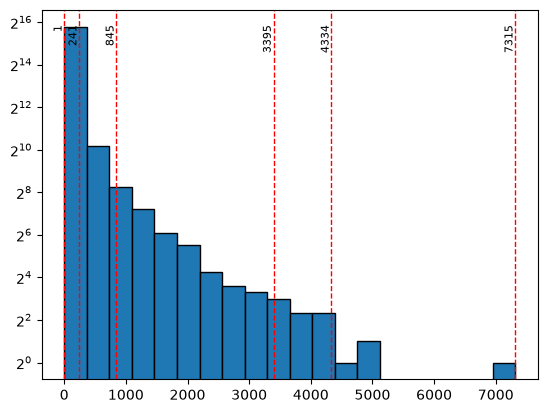

In [99]:
# Create histogram
plt.hist(anch_june["month"], bins=20, edgecolor='black')

# Create vertical lines
lines = [
    anch_june["month"].min(),               # min value
    anch_june["month"].quantile(.95),       # 95th percentile
    anch_june["month"].nlargest(500).min(), # 500th largest value
    # anch_june["month"].nlargest(150).min(), # 20th largest value
    # anch_june["month"].nlargest(50).min(),  # 20th largest value
    anch_june["month"].nlargest(20).min(),  # 20th largest value
    anch_june["month"].nlargest(5).min(),   # 5th largest value
    anch_june["month"].max()                # max value
]

# Add the values
for x in lines:
    
    plt.axvline(
        x, color = "red",
        linestyle="--", linewidth=1)
    
    plt.text(
        x, plt.ylim()[1], f"{x:.0f}",
        rotation=90, va="top",
        ha="right", fontsize=8
    )

# plot Y-axis but log2
plt.yscale("log", base=2)

plt.show()

## Insights

In [100]:
# top one anchorage points
anch_june.sort_values("month", ascending=False).head(1)

,s2id,day_mean,month,dock,iso3,country,port,geometry
218499,35ad9741,270.93,7315,False,CHN,China,Shanghai,POINT (121.92093 31.10686)


In [101]:
# top 5 anchorage points
anch_june.sort_values("month", ascending=False).head()

,s2id,day_mean,month,dock,iso3,country,port,geometry
218499,35ad9741,270.93,7315,False,CHN,China,Shanghai,POINT (121.92093 31.10686)
219253,35adc0e7,179.96,4859,False,CHN,China,Shanghai,POINT (122.05758 31.24858)
111827,2e417513,179.22,4839,True,IDN,Indonesia,Bakauheni,POINT (105.75574 -5.86945)
348380,47c480bd,167.33,4518,False,NLD,Netherlands (Kingdom of the),NLD-460,POINT (3.86346 51.3467)
432170,6d0d482d,160.52,4334,True,NZL,New Zealand,Orakei,POINT (174.81045 -36.84895)


In [108]:
# the top 5 ports
anch_june.groupby(["country","port"])["month"] \
    .sum().reset_index() \
    .sort_values("month", ascending=False).head(5)

,country,port,month
2248,China,Shanghai,23364
622,Belgium,Antwerp,11132
5917,Korea (the Republic of),Busan,10185
5934,Korea (the Republic of),Incheon,9580
2217,China,Ningbo,9075


In [110]:
# the top 5 countries
anch_june.groupby(["country"])["month"] \
    .sum().reset_index() \
    .sort_values("month", ascending=False).head(5)

,country,month
31,China,300052
196,United States of America (the),289740
136,Norway,207166
91,Italy,148483
60,France,127049


In [106]:
# the total of visits
print(anch_june["month"].sum())

3014368


## Export for WebMap

In [ ]:
# export anchorage june summary to GeoJSON with explicit crs 4326
anch_june.set_crs("EPSG:4326", allow_override=True) \
    .to_file(
        "./data/output/anch_june.geojson",
        driver="GeoJSON"
    )

In [ ]:
# export the timeseries dict to JSON
import json

with open("./data/timeSeries.json", "w", encoding="utf-8") as f:
    json.dump(
        timeseries,
        f,
        # indent=2,
        separators=(",", ":"),
        ensure_ascii=False
    )

In [ ]:
# export aoi to json
aoi.to_json(
    "./data/searchIndex.json",
    orient = "records",
    indent = 4
)

## Built voayges lines

In order to built the voyages polylines for each vessel. Several steps need to be taken:
- Reorganize the voyages GeoDataFrame in the right sequential order
- Built one lineString per vessel

In [ ]:
# import libraries
from shapely.geometry import LineString

In [ ]:
# get spatial column from anch_gdf
voy_df = voy_long.merge(
    anch_gdf[["s2id","geometry"]],
    on= "s2id",
    how= 'left'
)

In [ ]:
# df to geodataframe
voy_gdf = gpd.GeoDataFrame(
    voy_df, geometry= 'geometry',
    crs="EPSG:4326"  # WGS84 longitude/latitude
    )

voy_gdf.head()

In [ ]:
# building a single polyline per `vessel_id`
gdf = voy_gdf \
    .drop(columns=["ssvid","trip_id", "position"]) \
    .dropna(subset='geometry') \
    .sort_values(["vessel_id", "timestamp"]) \
    .groupby(["vessel_id"])["geometry"] \
    .apply(lambda g: LineString(g.tolist() if len(g) > 1 else None)) \
    .reset_index(name= 'geometry') \
    .pipe(gpd.GeoDataFrame, geometry="geometry", crs=voy_gdf.crs) 

In [ ]:
# inspect dataframe
print(gdf.nunique())
print()
print(gdf.shape)

This didn't worked. Single polylines per vessel does not reflect vessel voyages. It looks like lines go across continents in straight paths. Filtering data to the most recent month June 2026 which has the most global frequent time difference did not worked.

In [ ]:
# building two-segment lines per `vessel_id` and `trip_id`
gdf = voy_gdf \
    .drop(columns=["ssvid", "position"]) \
    .dropna(subset='geometry') \
    .sort_values(["vessel_id", "timestamp"]) \
    .groupby(["vessel_id", "trip_id"])["geometry"] \
    .apply(lambda g: LineString(g.tolist() if len(g) > 1 else None)) \
    .reset_index(name= 'geometry') \
    .pipe(gpd.GeoDataFrame, geometry="geometry", crs=voy_gdf.crs) 


In [ ]:
# inspect dataframe
print(gdf.nunique())
print()
print(gdf.shape)

This didn't worked. Two points lines per vessel and trip does not reflect vessel voyages. It looks like lines go across continents in straight paths. Filtering data to the most recent month June 2026 which has the most global frequent time difference did not worked.